In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/AER/CPS1988.csv"
df = pd.read_csv(url)

In [51]:
df.head()

,rownames,wage,education,experience,ethnicity,smsa,region,parttime
0,1,354.94,7,45,cauc,yes,northeast,no
1,2,123.46,12,1,cauc,yes,northeast,yes
2,3,370.37,9,9,cauc,yes,northeast,no
3,4,754.94,11,46,cauc,yes,northeast,no
4,5,593.54,12,36,cauc,yes,northeast,no


In [52]:
df.drop(columns = ['rownames'], inplace = True)
df.head()

,wage,education,experience,ethnicity,smsa,region,parttime
0,354.94,7,45,cauc,yes,northeast,no
1,123.46,12,1,cauc,yes,northeast,yes
2,370.37,9,9,cauc,yes,northeast,no
3,754.94,11,46,cauc,yes,northeast,no
4,593.54,12,36,cauc,yes,northeast,no


**Basic Statistics**

| Column Name | Type | Description |
|-------------|------|-------------|
| **wage** | Continuous | Hourly wage of the individual (target variable) |
| **education** | Continuous | Number of years of education completed |
| **experience** | Continuous | Number of years of work experience |
| **ethnicity** | Categorical | Ethnic group of the individual (e.g., cauc = Caucasian) |
| **smsa** | Categorical / Binary | Indicates whether the person lives in a metropolitan area (**yes = urban**, **no = non-urban**) |
| **region** | Categorical | Geographic region where the individual lives (e.g., northeast, south, west, etc.) |
| **parttime** | Categorical / Binary | Employment type (**yes = part-time**, **no = full-time**) |

In [53]:
df.describe()

,wage,education,experience
count,28155.000000,28155.000000,28155.000000
mean,603.726846,13.067874,18.199929
std,453.547350,2.899682,13.079233
min,50.050000,0.000000,-4.000000
25%,308.640000,12.000000,8.000000
50%,522.320000,12.000000,16.000000
75%,783.480000,15.000000,27.000000
max,18777.200000,18.000000,63.000000


In [54]:
df.dtypes

wage          float64
education       int64
experience      int64
ethnicity      object
smsa           object
region         object
parttime       object
dtype: object

In [55]:
df.shape

(28155, 7)

**Missing values**

In [56]:
df.isnull().sum()

wage          0
education     0
experience    0
ethnicity     0
smsa          0
region        0
parttime      0
dtype: int64

## **Understand Target variable(wage)**

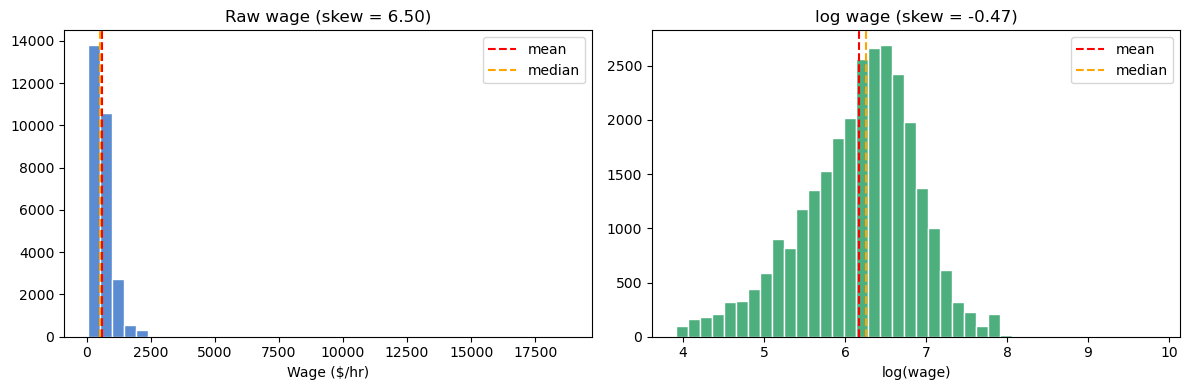

In [57]:
# Raw vs log wage side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw wage
axes[0].hist(df['wage'], bins = 40, color = '#5B8BD0', edgecolor = 'white')
axes[0].set_title(f"Raw wage (skew = {df['wage'].skew():.2f})")
axes[0].set_xlabel('Wage ($/hr)')
axes[0].axvline(df['wage'].mean(), color = 'red', linestyle = '--', label='mean')
axes[0].axvline(df['wage'].median(), color = 'orange', linestyle = '--', label='median')
axes[0].legend()

# Log wage
df['log_wage'] = np.log(df['wage'])
axes[1].hist(df['log_wage'], bins = 40, color = '#4CAF7D', edgecolor = 'white')
axes[1].set_title(f"log wage (skew = {df['log_wage'].skew():.2f})")
axes[1].set_xlabel('log(wage)')
axes[1].axvline(df['log_wage'].mean(), color = 'red', linestyle = '--', label = 'mean')
axes[1].axvline(df['log_wage'].median(), color = 'orange', linestyle = '--', label = 'median')
axes[1].legend()

plt.tight_layout()
plt.show()

| Skew Value | Interpretation |
|------------|----------------|
| skew ≈ 0 | Symmetric / Normal |
| skew > 0 | Right-skewed |
| skew < 0 | Left-skewed |
| skew ≥ 1 or ≤ -1 | Highly skewed |

In [58]:
from scipy import stats

# Normalty test (using sample of 200 - Shapiro needs n < 5000)
stat, p = stats.shapiro(df['log_wage'].sample(200, random_state = 42))
print(f"Shapiro-Wilk on log(wage): p = {p:.4f}")
print("Approximately normal!" if p > 0.05 else "Still not normal")

Shapiro-Wilk on log(wage): p = 0.0022
Still not normal


## Shapiro–Wilk Normality Test

The **Shapiro–Wilk test** is used to statistically check whether a variable follows a normal distribution.

### Hypotheses
- **H₀:** Data is normally distributed
- **H₁:** Data is not normally distributed

### Decision Rule
- **p > 0.05** → Approximately normal ✓
- **p ≤ 0.05** → Not normal ✗

### Why did `log_wage` fail?
Although the log transformation reduced skewness and improved symmetry, the Shapiro–Wilk test still rejected normality because it is highly sensitive to small deviations, especially in the tails. Real-world wage data is rarely perfectly normal.

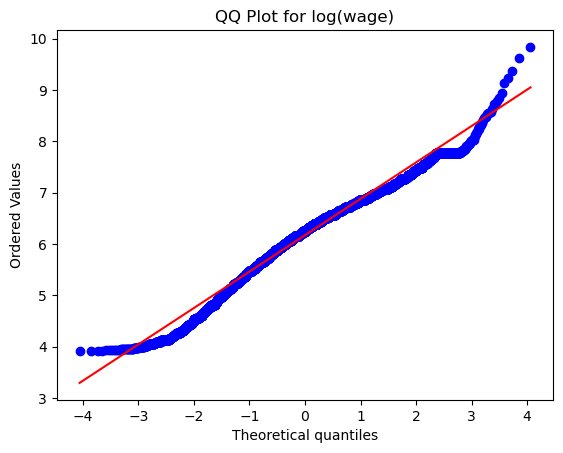

In [60]:
# QQ - plot

stats.probplot(df['log_wage'], dist = 'norm', plot = plt)
plt.title('QQ Plot for log(wage)')
plt.show()

## Q-Q Plot Interpretation

A **Q-Q (Quantile–Quantile) plot** compares the data distribution with a theoretical normal distribution.

- If points lie close to the straight line → Data is approximately normal ✓
- If points deviate from the line → Data is not perfectly normal ✗

For `log_wage`, most points follow the line, while slight deviations appear in the tails. This indicates **approximate normality with minor tail deviations**, making it suitable for further analysis.